# **UCI HAR - P-Mix + Contrastive SSL (PyTorch)**
- 참고 논문 : P-Mix: A Data Augmentation Method for Contrastive Learning Based Human Activity Recognition

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import time
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [45]:
# GPU 가속 공식 설정 (Colab 환경 대응)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [46]:
TRAIN = "train/"
TEST = "test/"

# 구글 드라이브 연동 경로 유지
DATASET_PATH = "/content/drive/MyDrive/AI/Dataset/UCI_HAR/"

In [47]:
# UCI HAR 데이터셋 상수 설정
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [48]:
# 1. X 데이터 로드 함수
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')
                row_clean = row_clean.strip()
                serie = row_clean.split(' ')
                serie_array = np.array(serie, dtype=np.float32)
                series_list.append(serie_array)

        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)

    # 파이토치:   (1, 0, 2) -> (샘플 수, 특성 수, 타임스텝 수)
    return np.transpose(X_signals, (1, 0, 2))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("=== X Data Shape (PyTorch Style) ===")
print("X_train shape (Batch, Channels, Timesteps):", X_train.shape) # (7352, 9, 128)
print("X_test shape (Batch, Channels, Timesteps):", X_test.shape)   # (2947, 9, 128)

=== X Data Shape (PyTorch Style) ===
X_train shape (Batch, Channels, Timesteps): (7352, 9, 128)
X_test shape (Batch, Channels, Timesteps): (2947, 9, 128)


In [49]:
# 2. y 데이터 로드 함수 (정수형 레이블 그대로 유지)
def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    # 파이토치 CrossEntropyLoss는 target으로 Long(int64) 타입을 요구하므로 np.int64로 설정
    return np.array(labels, dtype=np.int64) - 1


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("=== y Data Shape ===")
print("y_train shape (정수 인덱스):", y_train.shape) # (7352,)
print("y_test shape (정수 인덱스):", y_test.shape)   # (2947,)
print("y_train 앞 5개 샘플:", y_train[:5])

=== y Data Shape ===
y_train shape (정수 인덱스): (7352,)
y_test shape (정수 인덱스): (2947,)
y_train 앞 5개 샘플: [4 4 4 4 4]


# Model Building

P-Mix Data Augmentation 기법 구현 (논문 핵심)

In [55]:
class PMixAugmentation:
    def __init__(self, k=4, alpha=0.7):
        self.k = k          # Time split patch 개수
        self.alpha = alpha  # Channel mixing ratio

    def transform(self, X):
        B, C, T = X.shape
        if B <= 1:
            return X

        # --- [Step 1] Time Patch-Mix ---
        perm_idx = torch.randperm(B, device=X.device)
        X_prime = X[perm_idx]
        split_pts = np.linspace(0, T, self.k + 1, dtype=int)

        patches = []
        for j in range(self.k):
            start, end = split_pts[j], split_pts[j+1]
            if j % 2 == 0:
                patches.append(X[:, :, start:end])
            else:
                patches.append(X_prime[:, :, start:end])
        X_time_mixed = torch.cat(patches, dim=2)

        # --- [Step 2] Channel Patch-Mix ---
        perm_idx2 = torch.randperm(B, device=X.device)
        X_double_prime = X_time_mixed[perm_idx2]
        c_mix = max(1, int(self.alpha * C))

        X_augmented = X_double_prime.clone()
        for i in range(B):
            rand_channels = torch.randperm(C, device=X.device)[:c_mix]
            X_augmented[i, rand_channels, :] = X_time_mixed[i, rand_channels, :]

        return X_augmented

MODEL BUILDING (SSL 전용 Encoder + Projector + Classifier)

In [ ]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock1D, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return self.relu(out)

class HAREncoder(nn.Module):
    def __init__(self, in_channels=9):
        super(HAREncoder, self).__init__()
        self.prep_block = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, stride=1, padding=3, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU()
        )
        self.layer1 = nn.Sequential(ResidualBlock1D(64, 64, stride=1), ResidualBlock1D(64, 64, stride=1))
        self.layer2 = nn.Sequential(ResidualBlock1D(64, 128, stride=2), ResidualBlock1D(128, 128, stride=1))
        self.layer3 = nn.Sequential(ResidualBlock1D(128, 256, stride=2), ResidualBlock1D(256, 256, stride=1))
        self.layer4 = nn.Sequential(ResidualBlock1D(256, 512, stride=2), ResidualBlock1D(512, 512, stride=1))
        self.out_features = 512

    def forward(self, x):
        x = self.prep_block(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        return F.adaptive_avg_pool1d(x, 1).view(x.size(0), -1)

class SimCLRFramework(nn.Module):
    def __init__(self, encoder, projection_dim=128):
        super(SimCLRFramework, self).__init__()
        self.encoder = encoder
        self.projector = nn.Sequential(
            nn.Linear(encoder.out_features, 256),
            nn.ReLU(),
            nn.Linear(256, projection_dim)
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projector(h)
        return F.normalize(z, p=2, dim=1)

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.cos_sim = nn.CosineSimilarity(dim=-1)

    def forward(self, z_orig, z_aug):
        batch_size = z_orig.size(0)
        representations = torch.cat([z_orig, z_aug], dim=0)
        similarity_matrix = self.cos_sim(representations.unsqueeze(1), representations.unsqueeze(0)) / self.temperature

        mask = torch.eye(2 * batch_size, device=z_orig.device).bool()
        similarity_matrix.masked_fill_(mask, -9e15)

        targets = torch.cat([
            torch.arange(batch_size, 2 * batch_size, device=z_orig.device),
            torch.arange(0, batch_size, device=z_orig.device)
        ], dim=0)
        return nn.CrossEntropyLoss()(similarity_matrix, targets)

class HARClassifier(nn.Module):
    def __init__(self, encoder, num_classes=6):
        super(HARClassifier, self).__init__()
        self.encoder = encoder
        self.fc = nn.Sequential(
            nn.Linear(encoder.out_features, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        h = self.encoder(x)
        return self.fc(h)

CUSTOM CALLBACKS CLASS (Keras 라이브러리 커스텀 이식)

In [56]:
class PyTorchModelCheckpoint:
    def __init__(self, filepath="best_model.pt", monitor="val_accuracy", mode="max"):
        self.filepath = filepath
        self.monitor = monitor
        self.mode = mode
        self.best_value = float('-inf') if mode == "max" else float('inf')

    def __call__(self, current_value, model):
        is_improved = (self.mode == "max" and current_value > self.best_value) or \
                      (self.mode == "min" and current_value < self.best_value)
        if is_improved:
            print(f"🔥 [{self.monitor}] 개선 수치 수렴: {self.best_value:.5f} -> {current_value:.5f}. 모델 가중치 저장 파일 갱신: {self.filepath}")
            self.best_value = current_value
            torch.save(model.state_dict(), self.filepath)

class PyTorchEarlyStopping:
    def __init__(self, patience=25, monitor="val_accuracy", mode="max"):
        self.patience = patience
        self.monitor = monitor
        self.mode = mode
        self.counter = 0
        self.best_value = float('-inf') if mode == "max" else float('inf')
        self.early_stop = False

    def __call__(self, current_value):
        is_improved = (self.mode == "max" and current_value > self.best_value) or \
                      (self.mode == "min" and current_value < self.best_value)
        if is_improved:
            self.best_value = current_value
            self.counter = 0
        else:
            self.counter += 1
            print(f"📉 EarlyStopping 카운트 가산: {self.counter}/{self.patience} (현재 최적치: {self.best_value:.5f})")
            if self.counter >= self.patience:
                self.early_stop = True

PIPELINE EXECUTION (Pre-training -> Fine-tuning)

In [57]:
# 전처리 텐서 로더 준비 (validation_split=0.2 연동)
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.long)

full_dataset = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_tensor_y = torch.tensor(y_test, dtype=torch.long)
test_loader = DataLoader(TensorDataset(test_tensor_X, test_tensor_y), batch_size=16, shuffle=False)

# 히스토리 컨테이너 정의
history = {'ssl_loss': [], 'clf_train_loss': [], 'clf_val_loss': [], 'clf_train_acc': [], 'clf_val_acc': []}

# --- [STAGE 1] SSL Pre-training ---
print("\n>>> [STAGE 1] Start P-Mix Self-Supervised Learning Pre-training")
encoder_net = HAREncoder(in_channels=9).to(device)
ssl_model = SimCLRFramework(encoder_net, projection_dim=128).to(device)

p_mix = PMixAugmentation(k=4, alpha=0.7)
criterion_ssl = NTXentLoss(temperature=0.5)
optimizer_ssl = optim.Adam(ssl_model.parameters(), lr=0.001)

for epoch in range(1, 31): # Pre-training 30에폭
    ssl_model.train()
    ssl_loss = 0.0
    for X_batch, _ in train_loader:
        X_batch = X_batch.to(device)
        X_aug = p_mix.transform(X_batch)

        optimizer_ssl.zero_grad()
        z_orig = ssl_model(X_batch)
        z_aug = ssl_model(X_aug)

        loss = criterion_ssl(z_orig, z_aug)
        loss.backward()
        optimizer_ssl.step()
        ssl_loss += loss.item()

    avg_ssl_loss = ssl_loss / len(train_loader)
    history['ssl_loss'].append(avg_ssl_loss)
    print(f"SSL Epoch {epoch:02d}/30 | NT-Xent Loss: {avg_ssl_loss:.4f}")

# --- [STAGE 2] Downstream Fine-tuning (Callbacks 통합 연동) ---
print("\n>>> [STAGE 2] Start Linear Evaluation & Fine-tuning with Callbacks")
classifier = HARClassifier(encoder_net, num_classes=6).to(device)

criterion_ce = nn.CrossEntropyLoss()
optimizer_clf = optim.Adam(classifier.parameters(), lr=0.001)

# 콜백 인스턴스화 선언
checkpoint_path = "UCI_HAR_P_Mix_SSL_best.pt"
checkpoint_callback = PyTorchModelCheckpoint(filepath=checkpoint_path, monitor="val_accuracy", mode="max")
early_stopping_callback = PyTorchEarlyStopping(patience=25, monitor="val_accuracy", mode="max")
lr_scheduler = ReduceLROnPlateau(optimizer_clf, mode='min', factor=0.2, patience=8, min_lr=0.00001)

for epoch in range(1, 151): # 최대 150에폭
    classifier.train()
    train_loss, correct_train, total_train = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer_clf.zero_grad()
        logits = classifier(X_batch)
        loss = criterion_ce(logits, y_batch)
        loss.backward()
        optimizer_clf.step()

        train_loss += loss.item() * X_batch.size(0)
        _, predicted = torch.max(logits, 1)
        correct_train += (predicted == y_batch).sum().item()
        total_train += y_batch.size(0)

    avg_train_loss = train_loss / total_train
    avg_train_acc = correct_train / total_train

    # 검증 루프
    classifier.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = classifier(X_batch)
            loss = criterion_ce(logits, y_batch)

            val_loss += loss.item() * X_batch.size(0)
            _, predicted = torch.max(logits, 1)
            correct_val += (predicted == y_batch).sum().item()
            total_val += y_batch.size(0)

    avg_val_loss = val_loss / total_val
    avg_val_acc = correct_val / total_val

    # 히스토리 기록 축적
    history['clf_train_loss'].append(avg_train_loss)
    history['clf_val_loss'].append(avg_val_loss)
    history['clf_train_acc'].append(avg_train_acc)
    history['clf_val_acc'].append(avg_val_acc)

    # 콜백 시그널 전송 및 작동
    lr_scheduler.step(avg_val_loss)
    current_lr = optimizer_clf.param_groups[0]['lr']
    print(f"Epoch {epoch:03d}/150 - loss: {avg_train_loss:.4f} - accuracy: {avg_train_acc:.4f} - val_loss: {avg_val_loss:.4f} - val_accuracy: {avg_val_acc:.4f} - lr: {current_lr:.6f}")

    checkpoint_callback(current_value=avg_val_acc, model=classifier)
    early_stopping_callback(current_value=avg_val_acc)

    if early_stopping_callback.early_stop:
        print("🚨 조기 종료 규칙 컴파일링 가동: 수렴 중지 진단 완료.")
        break

# 최적 가중치 가 복원 로드
classifier.load_state_dict(torch.load(checkpoint_path))


>>> [STAGE 1] Start P-Mix Self-Supervised Learning Pre-training
SSL Epoch 01/30 | NT-Xent Loss: 2.9593
SSL Epoch 02/30 | NT-Xent Loss: 2.6875
SSL Epoch 03/30 | NT-Xent Loss: 2.5316
SSL Epoch 04/30 | NT-Xent Loss: 2.4640
SSL Epoch 05/30 | NT-Xent Loss: 2.3705
SSL Epoch 06/30 | NT-Xent Loss: 2.3521
SSL Epoch 07/30 | NT-Xent Loss: 2.3211
SSL Epoch 08/30 | NT-Xent Loss: 2.3035
SSL Epoch 09/30 | NT-Xent Loss: 2.2896
SSL Epoch 10/30 | NT-Xent Loss: 2.2732
SSL Epoch 11/30 | NT-Xent Loss: 2.2522
SSL Epoch 12/30 | NT-Xent Loss: 2.2295
SSL Epoch 13/30 | NT-Xent Loss: 2.2365
SSL Epoch 14/30 | NT-Xent Loss: 2.2166
SSL Epoch 15/30 | NT-Xent Loss: 2.2117
SSL Epoch 16/30 | NT-Xent Loss: 2.2126
SSL Epoch 17/30 | NT-Xent Loss: 2.1825
SSL Epoch 18/30 | NT-Xent Loss: 2.1715
SSL Epoch 19/30 | NT-Xent Loss: 2.1677
SSL Epoch 20/30 | NT-Xent Loss: 2.1637
SSL Epoch 21/30 | NT-Xent Loss: 2.1429
SSL Epoch 22/30 | NT-Xent Loss: 2.1296
SSL Epoch 23/30 | NT-Xent Loss: 2.1294
SSL Epoch 24/30 | NT-Xent Loss: 2.1210

<All keys matched successfully>

# EVALUATION

📌Embedding Space t-SNE
- 원본 데이터 → 시간축 믹스(Time Patch-Mix) → 채널축 믹스(Channel Patch-Mix) 완료 후 공간
- 어떤 원본 샘플들이 조합되어 증강 샘플이 되었는지, 위치가 어떻게 이동했는지 추적

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/tmp/ipykernel_2079/1829375644.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', B) # 각 샘플 고유의 색상 지정


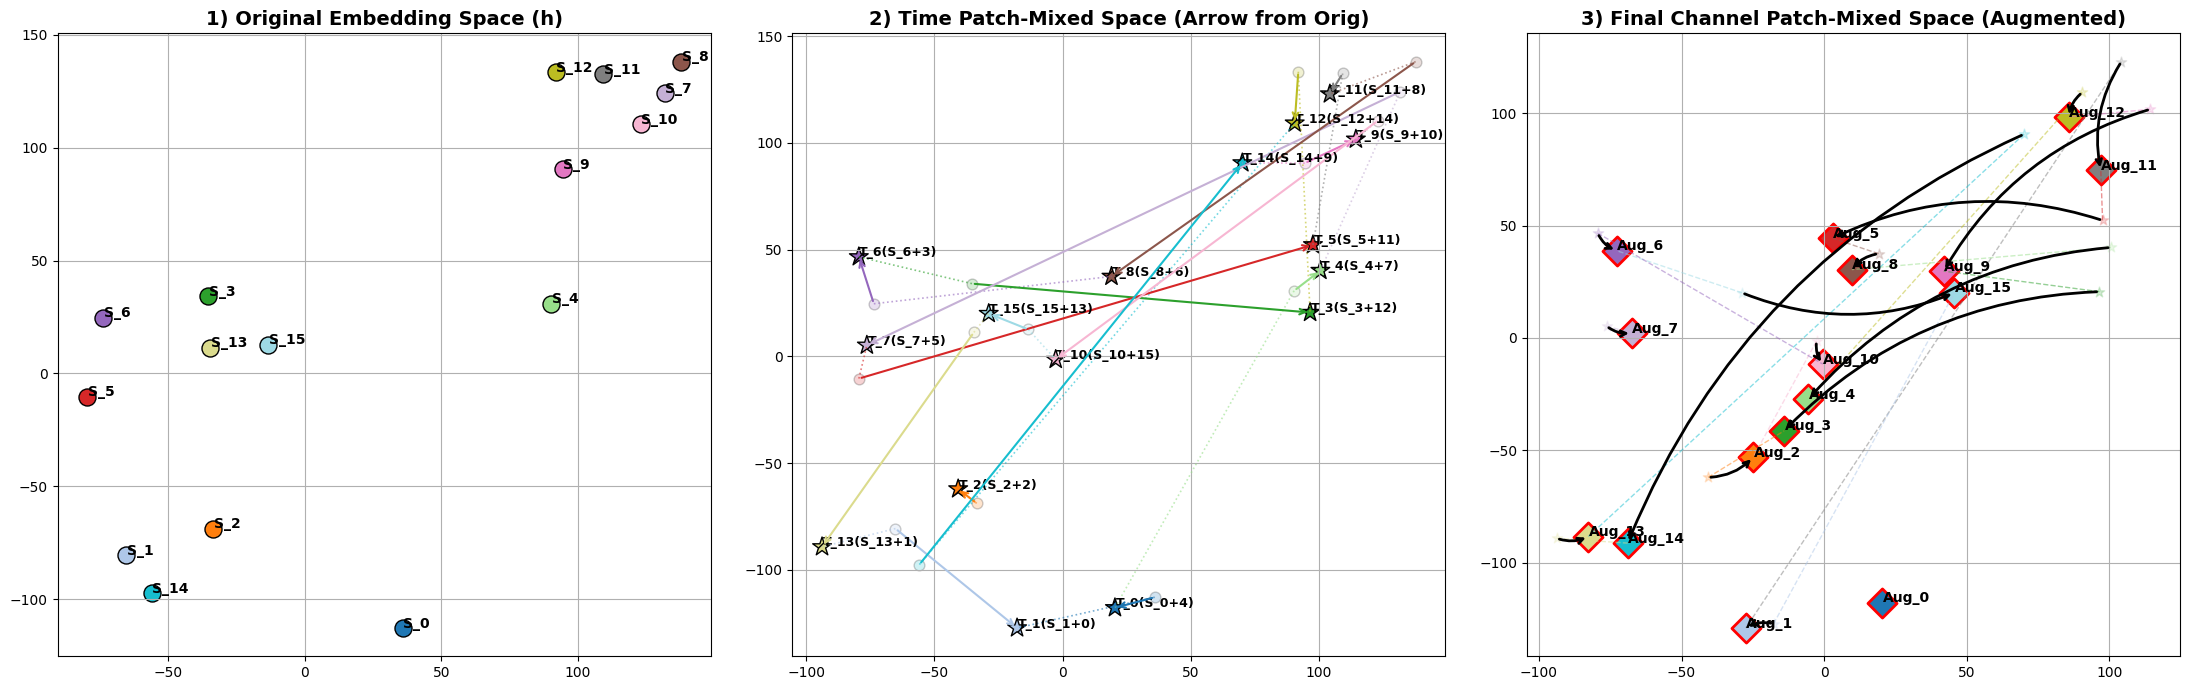

In [64]:
from sklearn.manifold import TSNE

# =================================================================
# 1. 추적 기능이 탑재된 P-Mix 증강 클래스 (시각화용 리팩토링)
# =================================================================
class TrackablePMixAugmentation:
    def __init__(self, k=4, alpha=0.7):
        self.k = k
        self.alpha = alpha

    def transform_with_tracks(self, X):
        """
        시각화를 위해 연산 과정의 인덱스 변화를 함께 반환합니다.
        """
        B, C, T = X.shape

        # --- [Step 1] Time Patch-Mix ---
        perm_idx1 = torch.randperm(B, device=X.device)
        X_prime = X[perm_idx1]
        split_pts = np.linspace(0, T, self.k + 1, dtype=int)

        patches = []
        for j in range(self.k):
            start, end = split_pts[j], split_pts[j+1]
            if j % 2 == 0:
                patches.append(X[:, :, start:end])
            else:
                patches.append(X_prime[:, :, start:end])
        X_time_mixed = torch.cat(patches, dim=2)

        # --- [Step 2] Channel Patch-Mix ---
        perm_idx2 = torch.randperm(B, device=X.device)
        X_double_prime = X_time_mixed[perm_idx2]
        c_mix = max(1, int(self.alpha * C))

        X_augmented = X_double_prime.clone()
        mixed_channels_log = []
        for i in range(B):
            rand_channels = torch.randperm(C, device=X.device)[:c_mix]
            X_augmented[i, rand_channels, :] = X_time_mixed[i, rand_channels, :]
            mixed_channels_log.append(rand_channels.cpu().numpy())

        # X: 원본, X_time_mixed: 시간축 믹스, X_augmented: 최종 증강
        # perm_idx1, perm_idx2: 어떤 샘플끼리 섞였는지 알려주는 이정표
        return X_time_mixed, X_augmented, perm_idx1.cpu().numpy(), perm_idx2.cpu().numpy()


# =================================================================
# 2. 임베딩 공간 데이터 추출 (하나의 배치를 타겟으로 설정)
# =================================================================
# 1) 단일 배치 추출 (데이터 로더에서 배치 하나만 가져옴)
data_iter = iter(test_loader)
X_batch, y_batch = next(data_iter)

B, C, T = X_batch.shape
X_batch = X_batch.to(device)

# 추적 기능이 있는 P-Mix 선언 및 실행
trackable_pmix = TrackablePMixAugmentation(k=4, alpha=0.7)
X_time_mixed, X_augmented, perm1, perm2 = trackable_pmix.transform_with_tracks(X_batch)

# 2) 모델의 Encoder 특징 추출 공간(h) 벡터 획득
encoder_net.eval()
with torch.no_grad():
    h_orig = encoder_net(X_batch).cpu().numpy()
    h_time = encoder_net(X_time_mixed).cpu().numpy()
    h_final = encoder_net(X_augmented).cpu().numpy()

# t-SNE 차원축소를 위해 세 공간의 벡터를 하나로 합쳐 한 번에 변환 (공동 공간 매핑)
all_embeddings = np.concatenate([h_orig, h_time, h_final], axis=0)

# t-SNE 변환 (배치 사이즈가 작으므로 perplexity는 작게 설정합니다)
tsne = TSNE(n_components=2, perplexity=min(5, B-1), random_state=42, n_iter=1000)
all_2d = tsne.fit_transform(all_embeddings)

# 다시 각각의 공간으로 평면 좌표 분할
tsne_orig = all_2d[:B]
tsne_time = all_2d[B:2*B]
tsne_final = all_2d[2*B:]


# =================================================================
# 3. 3단 임베딩 공간 시각화 및 관계성 추적 그래프 그리기
# =================================================================
plt.figure(figsize=(22, 7))
colors = plt.cm.get_cmap('tab20', B) # 각 샘플 고유의 색상 지정

# --- [Plot 1] 맨 처음 원본 데이터의 임베딩 공간 ---
plt.subplot(1, 3, 1)
for i in range(B):
    plt.scatter(tsne_orig[i, 0], tsne_orig[i, 1], color=colors(i), s=150, edgecolors='k', marker='o', label=f'S_{i}' if B<=8 else "")
    plt.text(tsne_orig[i, 0]+0.2, tsne_orig[i, 1]+0.2, f'S_{i}', fontsize=10, weight='bold')
plt.title('1) Original Embedding Space (h)', fontsize=14, weight='bold')
plt.grid(True)

# --- [Plot 2] 시간축 믹스만 했을 때의 임베딩 공간 ---
plt.subplot(1, 3, 2)
# 원본 위치 흐리게 배경에 깔아두기
for i in range(B):
    plt.scatter(tsne_orig[i, 0], tsne_orig[i, 1], color=colors(i), s=60, alpha=0.2, edgecolors='k')

# 시간축 믹스 점 찍기 및 화살표 연결
for i in range(B):
    # 시간축 믹스 결과물 i는 원본 i(본인)와 원본 perm1[i](상대)의 결합체입니다.
    src_self = i
    src_other = perm1[i]

    # 시간축 믹스 샘플 표현 (별 모양 마커)
    plt.scatter(tsne_time[i, 0], tsne_time[i, 1], color=colors(src_self), s=200, edgecolors='k', marker='*', hatch='//')
    plt.text(tsne_time[i, 0]+0.2, tsne_time[i, 1]+0.2, f'T_{i}(S_{src_self}+{src_other})', fontsize=9, weight='bold')

    # 본인 원본에서 시간 믹스 점으로 화살표 지시
    plt.annotate('', xy=(tsne_time[i, 0], tsne_time[i, 1]), xytext=(tsne_orig[src_self, 0], tsne_orig[src_self, 1]),
                 arrowprops=dict(arrowstyle="->", color=colors(src_self), lw=1.5, ls='-'))
    # 재조합된 상대 원본에서 시간 믹스 점으로 보조 점선 연결
    plt.plot([tsne_orig[src_other, 0], tsne_time[i, 0]], [tsne_orig[src_other, 1], tsne_time[i, 1]],
             color=colors(src_other), linestyle=':', alpha=0.6, lw=1.2)
plt.title('2) Time Patch-Mixed Space (Arrow from Orig)', fontsize=14, weight='bold')
plt.grid(True)

# --- [Plot 3] 채널축 믹스까지 완료한 최종 증강 임베딩 공간 ---
plt.subplot(1, 3, 3)
# 이전 단계인 시간축 믹스 위치 흐리게 배경에 깔기
for i in range(B):
    plt.scatter(tsne_time[i, 0], tsne_time[i, 1], color=colors(i), s=60, alpha=0.2, marker='*')

# 최종 채널 믹스 점 찍기 및 화살표 연결
for i in range(B):
    # 최종 채널 믹스 결과물 i는 시간믹스 i(본인 틀)와 시간믹스 perm2[i](상대 채널)의 결합체입니다.
    t_self = i
    t_other = perm2[i]

    # 최종 증강 샘플 표현 (다이아몬드 모양 마커)
    plt.scatter(tsne_final[i, 0], tsne_final[i, 1], color=colors(t_self), s=220, edgecolors='r', lw=2, marker='D')
    plt.text(tsne_final[i, 0]+0.2, tsne_final[i, 1]+0.2, f'Aug_{i}', fontsize=10, weight='bold')

    # 시간 믹스 위치에서 최종 증강 위치로 변형 추적 화살표
    plt.annotate('', xy=(tsne_final[i, 0], tsne_final[i, 1]), xytext=(tsne_time[t_self, 0], tsne_time[t_self, 1]),
                 arrowprops=dict(arrowstyle="->", color='black', lw=2, connectionstyle="arc3,rad=.2"))
    # 채널을 제공해준 기증 샘플과의 연동선
    plt.plot([tsne_time[t_other, 0], tsne_final[i, 0]], [tsne_time[t_other, 1], tsne_final[i, 1]],
             color=colors(t_other), linestyle='--', alpha=0.5, lw=1)

plt.title('3) Final Channel Patch-Mixed Space (Augmented)', fontsize=14, weight='bold')
plt.grid(True)

plt.tight_layout()
plt.show()

**💡 위 Embedding Space 해석 가이드**
- **1번 그림** : 가공되지 않은 순수 데이터 고유의 배치 내부 분포 상태
- **2번 그림** : 원본 샘플에서 출발한 **유색 실선 화살표**가 별모양의 시간축 믹스 샘플을 가리킵니다. 이때 믹싱 짝꿍이 된 소스 샘플로부터는 옅은 점선이 연결되어 결합 관계를 증명합니다.
- **3번 그림** : 시간축 믹스 샘플에서 최종 채널 구조가 재조합되면서 이동한 궤적이 **검은색 곡선 화살표**로 뚜렷하게 묘사되며, 테두리가 붉은 다이아몬드 형태로 최종 위치가 강조되어 있습니다.

📌 Best 기록 확인

In [65]:
# =================================================================
# 1. 가중치를 불러올 빈 모델 객체 생성 및 로드
# =================================================================
# 파이프라인에 정의된 뼈대 엔코더와 분류기를 먼저 선언합니다.
best_encoder = HAREncoder(in_channels=9).to(device)
best_model = HARClassifier(best_encoder, num_classes=6).to(device)

# 앞서 Stage 2 콜백을 통해 저장된 베스트 .pt 파일 가중치 로드
checkpoint_path = "UCI_HAR_P_Mix_SSL_best.pt"
best_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
print(f"▶ Successfully loaded best model weights from {checkpoint_path}")


# =================================================================
# 2. 데이터 평가를 위한 수동 함수 정의 (SSL 파이프라인 최적화)
# =================================================================
def evaluate_pytorch_model(model, X_data, y_data, batch_size=16):
    model.eval() # 평가 모드 활성화 (Dropout, BatchNorm 기능 동결)

    # 1. 넘파이 배열을 텐서로 변환
    if isinstance(X_data, torch.Tensor):
        eval_tensor_X = X_data.float()
    else:
        eval_tensor_X = torch.tensor(X_data, dtype=torch.float32)

    if isinstance(y_data, torch.Tensor):
        eval_tensor_y = y_data.long()
    else:
        eval_tensor_y = torch.tensor(y_data, dtype=torch.long)

    # [차원 검사 및 방어]
    # 만약 원본 데이터 축이 (B, 128, 9) 형태로 들어온 경우에만 (B, 9, 128)로 전환
    if eval_tensor_X.shape[1] != 9 and eval_tensor_X.shape[2] == 9:
        eval_tensor_X = eval_tensor_X.transpose(1, 2)

    # 2. 평가용 DataLoader 구성
    eval_dataset = TensorDataset(eval_tensor_X, eval_tensor_y)
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    # 하위 분류 모델의 분류 손실 함수 정의
    evaluation_criterion = nn.CrossEntropyLoss()

    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad(): # 역전파 gradient 연산 제외로 메모리 효율화
        for batch_X, batch_y in eval_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            outputs = model(batch_X)
            loss = evaluation_criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == batch_y).sum().item()
            total_samples += batch_X.size(0)

    avg_loss = total_loss / total_samples
    avg_acc = correct / total_samples
    return avg_loss, avg_acc


# =================================================================
# 3. Training & Test 데이터셋 최종 평가 및 출력
# =================================================================
print("\n" + "="*20 + " 최고 기록 성능 평가 " + "="*20)

# 1) X_train 전체 데이터셋에 대한 검증 수행
train_loss, train_acc = evaluate_pytorch_model(best_model, X_train, y_train, batch_size=16)
print(f"Training accuracy : {train_acc * 100:.2f}%")
print(f"Training loss     : {train_loss:.4f}")
print("-" * 53)

# 2) X_test (최종 평가 데이터셋)에 대한 검증 수행
test_loss, test_acc = evaluate_pytorch_model(best_model, X_test, y_test, batch_size=16)
print(f"Test accuracy     : {test_acc * 100:.2f}%")
print(f"Test loss         : {test_loss:.4f}")
print("=" * 53)

▶ Successfully loaded best model weights from UCI_HAR_P_Mix_SSL_best.pt

==================== 최고 기록 성능 평가 ====================
Training accuracy : 99.85%
Training loss     : 0.0061
-----------------------------------------------------
Test accuracy     : 94.84%
Test loss         : 0.2985


📌 Classification Report

In [66]:
# =================================================================
# [예측 파트] 최종 가중치가 로드된 모델로 테스트 데이터 예측 수행
# =================================================================
print("\n>>> Start Final Model Prediction on Test Dataset")
classifier.eval()  # 평가 모드 활성화

# 1. 데이터 준비 (TensorDataset 구성)
# X_test는 이미 (Samples, 9, 128) 규격으로 전처리되어 있다고 가정합니다.
test_tensor_X = torch.tensor(X_test, dtype=torch.float32)
test_dataset = TensorDataset(test_tensor_X)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

y_pred_list = []

with torch.no_grad():
    for batch_X in test_loader:
        inputs = batch_X[0].to(device)

        # [차원 정렬 방어 코드]
        # 모델 입력이 (B, 9, 128)을 기대하는데 (B, 128, 9)가 들어온 경우에만 전환
        if inputs.shape[1] != 9 and inputs.shape[2] == 9:
            inputs = inputs.transpose(1, 2)

        # 순전파 진행
        outputs = classifier(inputs)

        # 확률값 혹은 가장 높은 확률의 클래스 인덱스 추출
        _, predicted = torch.max(outputs, dim=1)

        # CPU로 이동 및 리스트 저장
        y_pred_list.extend(predicted.cpu().numpy())

# 넘파이 배열로 변환
y_pred = np.array(y_pred_list)

# =================================================================
# 2. 분류 리포트 및 결과 출력
# =================================================================
print("\n" + " "*16 + "Classification Report")
print("-" * 60)

# LABELS는 데이터 로딩 단계에서 정의한 ["WALKING", "WALKING_UPSTAIRS", ...] 리스트를 그대로 사용
# y_test는 이미 0~5 정수형 레이블로 변환되어 있음
print(classification_report(y_test, y_pred, target_names=LABELS, digits=4))

# 추가로 오차 행렬(Confusion Matrix)까지 확인하고 싶으시다면 아래 주석을 해제하세요.
# cm = confusion_matrix(y_test, y_pred)
# print("\nConfusion Matrix:")
# print(cm)


>>> Start Final Model Prediction on Test Dataset

                Classification Report
------------------------------------------------------------
                    precision    recall  f1-score   support

           WALKING     0.9937    0.9476    0.9701       496
  WALKING_UPSTAIRS     0.9978    0.9512    0.9739       471
WALKING_DOWNSTAIRS     0.9190    1.0000    0.9578       420
           SITTING     0.9260    0.8411    0.8815       491
          STANDING     0.8667    0.9530    0.9078       532
            LAYING     1.0000    1.0000    1.0000       537

          accuracy                         0.9484      2947
         macro avg     0.9505    0.9488    0.9485      2947
      weighted avg     0.9506    0.9484    0.9484      2947



📌 지표(Metrics) 계산 및 효율성(FLOPs/추론시간) 측정

In [61]:
from fvcore.nn import FlopCountAnalysis
from sklearn.metrics import precision_recall_fscore_support

def evaluate_model_efficiency_and_metrics_fixed(model, test_loader, device, input_size=(1, 9, 128)):
    model.eval()
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    dummy_input = torch.randn(*input_size).to(device)

    flops_analyzer = FlopCountAnalysis(model, dummy_input)
    flops_analyzer.unsupported_ops_warnings(False)
    total_flops = flops_analyzer.total()

    all_preds, all_targets, inference_times = [], [], []

    with torch.no_grad():
        for batch in test_loader:
            batch_X, batch_y = batch[0], batch[1] if len(batch) >= 2 else None
            inputs = batch_X.to(device) if isinstance(batch_X, torch.Tensor) else torch.tensor(batch_X, dtype=torch.float32).to(device)

            # 이중 축 전환 방어 메커니즘
            if inputs.shape[1] != input_size[1] and inputs.shape[2] == input_size[1]:
                inputs = inputs.transpose(1, 2)

            start_time = time.time()
            outputs = model(inputs)
            if device.type == 'cuda': torch.cuda.synchronize()
            inference_times.append((time.time() - start_time) * 1000 / inputs.size(0))

            all_preds.extend(torch.argmax(outputs, dim=1).cpu().numpy())
            if batch_y is not None:
                batch_y_cpu = batch_y.cpu().numpy() if isinstance(batch_y, torch.Tensor) else np.array(batch_y)
                all_targets.extend(np.argmax(batch_y_cpu, axis=1) if len(batch_y_cpu.shape) > 1 and batch_y_cpu.shape[1] > 1 else batch_y_cpu)

    all_preds, all_targets = np.array(all_preds), np.array(all_targets)
    print("="*50 + f"\n🥇 Metrics & Efficiency Evaluation\n" + "="*50)
    print(f"Parameters   : {total_params / 1e6:.4f} M\nFLOPs        : {total_flops / 1e6:.4f} M\nInference    : {np.mean(inference_times):.3f} ms/sample")

    if len(all_targets) > 0:
        accuracy = accuracy_score(all_targets, all_preds) * 100
        precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average='macro', zero_division=0)
        print(f"Accuracy     : {accuracy:.2f} %\nF1 Score     : {f1:.4f}\nRecall       : {recall:.4f}\nPrecision    : {precision:.4f}\n" + "="*50)
        return all_targets, all_preds
    return None, all_preds

targets, test_preds = evaluate_model_efficiency_and_metrics_fixed(model=classifier, test_loader=test_loader, device=device, input_size=(1, 9, 128))

encoder.layer1.0.shortcut, encoder.layer1.1.shortcut, encoder.layer2.1.shortcut, encoder.layer3.1.shortcut, encoder.layer4.1.shortcut


🥇 Metrics & Efficiency Evaluation
Parameters   : 3.9809 M
FLOPs        : 88.0087 M
Inference    : 0.491 ms/sample
Accuracy     : 94.84 %
F1 Score     : 0.9485
Recall       : 0.9488
Precision    : 0.9505


📌 Accuracy & Loss 그래프 (Stage 1 & Stage 2)

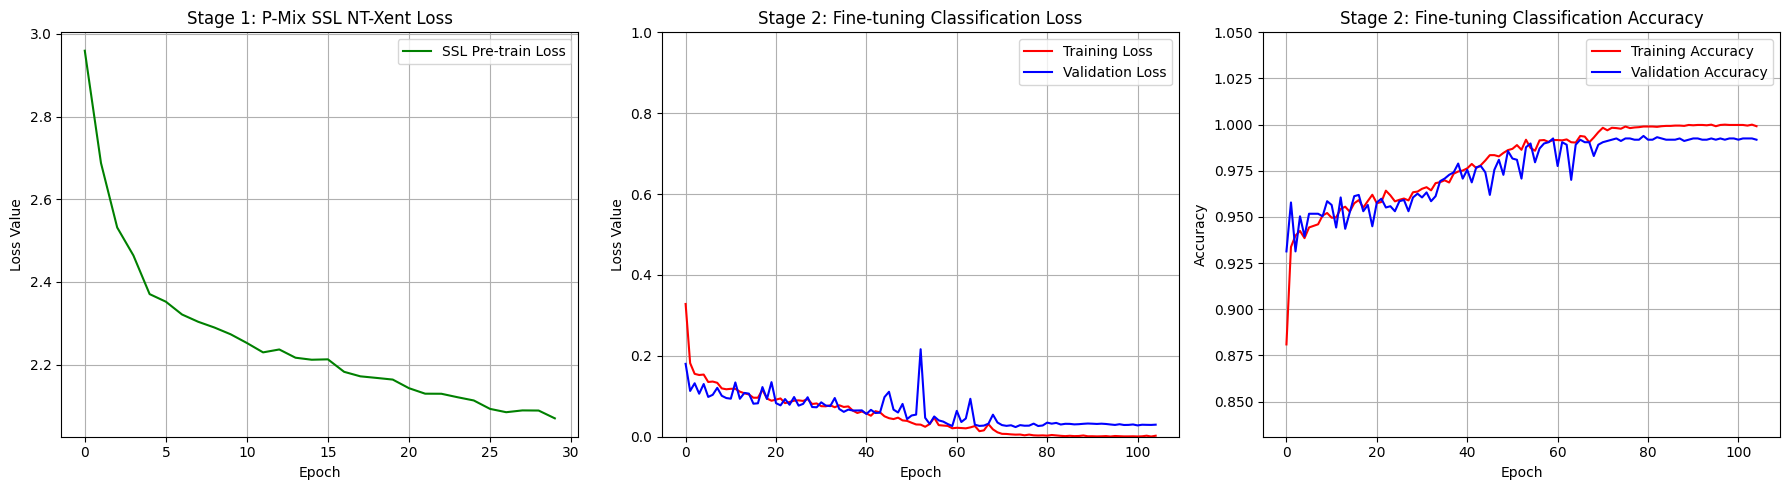

In [62]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history['ssl_loss'], 'g', label='SSL Pre-train Loss')
plt.title('Stage 1: P-Mix SSL NT-Xent Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss Value'); plt.legend(); plt.grid(True)

plt.subplot(1, 3, 2)
max_loss_val = max(max(history['clf_train_loss']), max(history['clf_val_loss']))
plt.ylim([0.0, max(1.0, max_loss_val * 1.1)])
plt.plot(history['clf_train_loss'], 'r', label='Training Loss')
plt.plot(history['clf_val_loss'], 'b', label='Validation Loss')
plt.title('Stage 2: Fine-tuning Classification Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss Value'); plt.legend(); plt.grid(True)

plt.subplot(1, 3, 3)
min_acc_val = min(min(history['clf_train_acc']), min(history['clf_val_acc']))
plt.ylim([max(0.0, min_acc_val - 0.05), 1.05])
plt.plot(history['clf_train_acc'], 'r', label='Training Accuracy')
plt.plot(history['clf_val_acc'], 'b', label='Validation Accuracy')
plt.title('Stage 2: Fine-tuning Classification Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True)

plt.tight_layout()
plt.show()

📌 혼동 행렬 (Confusion Matrix)

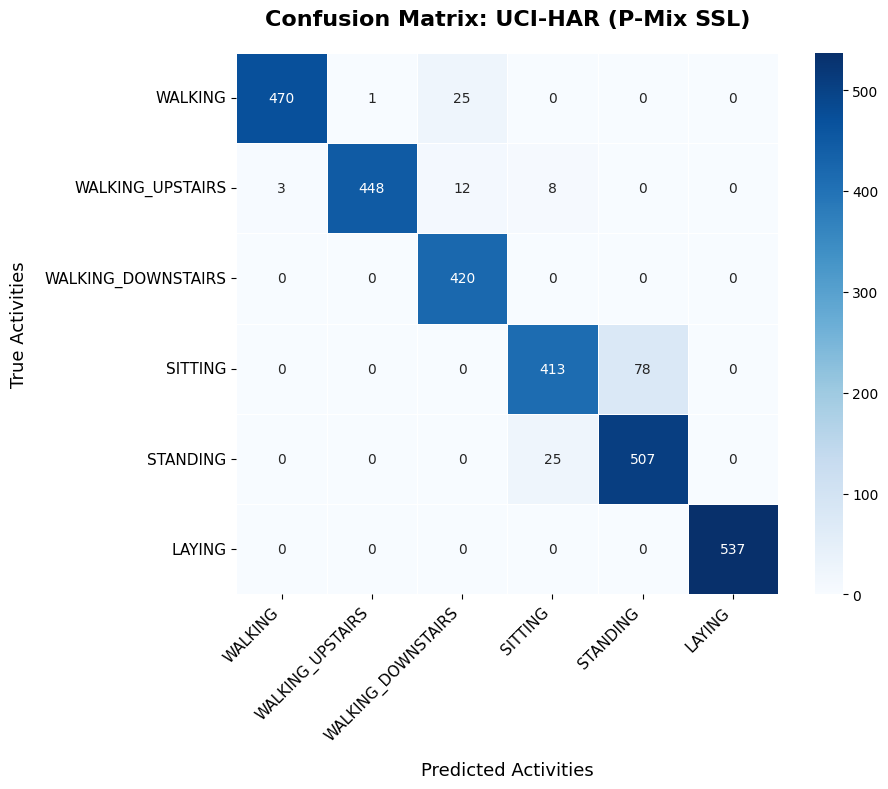

In [69]:
# 1. 혼동 행렬 계산
cm = confusion_matrix(y_test, y_pred)

# 2. Seaborn Heatmap 시각화
plt.figure(figsize=(10, 8))

# annot=True(값 표시), fmt='d'(정수형), cmap='Blues'(색상)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            square=True, linewidths=.5)

# 3. UCI-HAR 클래스명 정의 (앞서 정의한 LABELS 리스트)
class_names = ["WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
               "SITTING", "STANDING", "LAYING"]

# 축 레이블 설정
plt.title('Confusion Matrix: UCI-HAR (P-Mix SSL)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Activities', fontsize=13, labelpad=12)
plt.ylabel('True Activities', fontsize=13, labelpad=12)

# 클래스명 매핑 (눈금 위치 중앙 정렬)
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks + 0.5, class_names, rotation=45, ha='right', fontsize=11)
plt.yticks(tick_marks + 0.5, class_names, rotation=0, fontsize=11)

plt.tight_layout()
plt.show()